# Facets, Axis Guides, and Text Legends

This page covers the plotnine-extra APIs added or tightened for the 0.3.1
release: extended facets, per-panel position scales, ggh4x-style axis helpers,
and text-only legends.

The examples use explicit imports from `plotnine` and `plotnine_extra`, so each
feature's package is visible in the code.

## Setup

Guide helpers can be added to a plot or passed to position scales. Extended
facets such as `facet_wrap2()` and `facet_manual()` read those guide
specifications while drawing axes.

In [1]:
import pandas as pd
from plotnine import (
    aes,
    geom_col,
    geom_point,
    ggplot,
    guides,
    labs,
    scale_x_continuous,
    theme_minimal,
)
from plotnine_extra import (
    facet_manual,
    facet_wrap2,
    guide_axis_manual,
    guide_axis_nested,
    guide_stringlegend,
    scale_x_facet,
)

## Axis guides and per-panel scales

`guide_axis_manual()` sets breaks, labels, and label styling for a position
axis. `scale_x_facet()` and `scale_y_facet()` target individual facet panels
with selector expressions evaluated against the facet layout.

If more than one selector matches a panel, the first selector wins. Use
`scales="free_x"` or `scales="free_y"` when a facet needs independent panel
scales to replace.

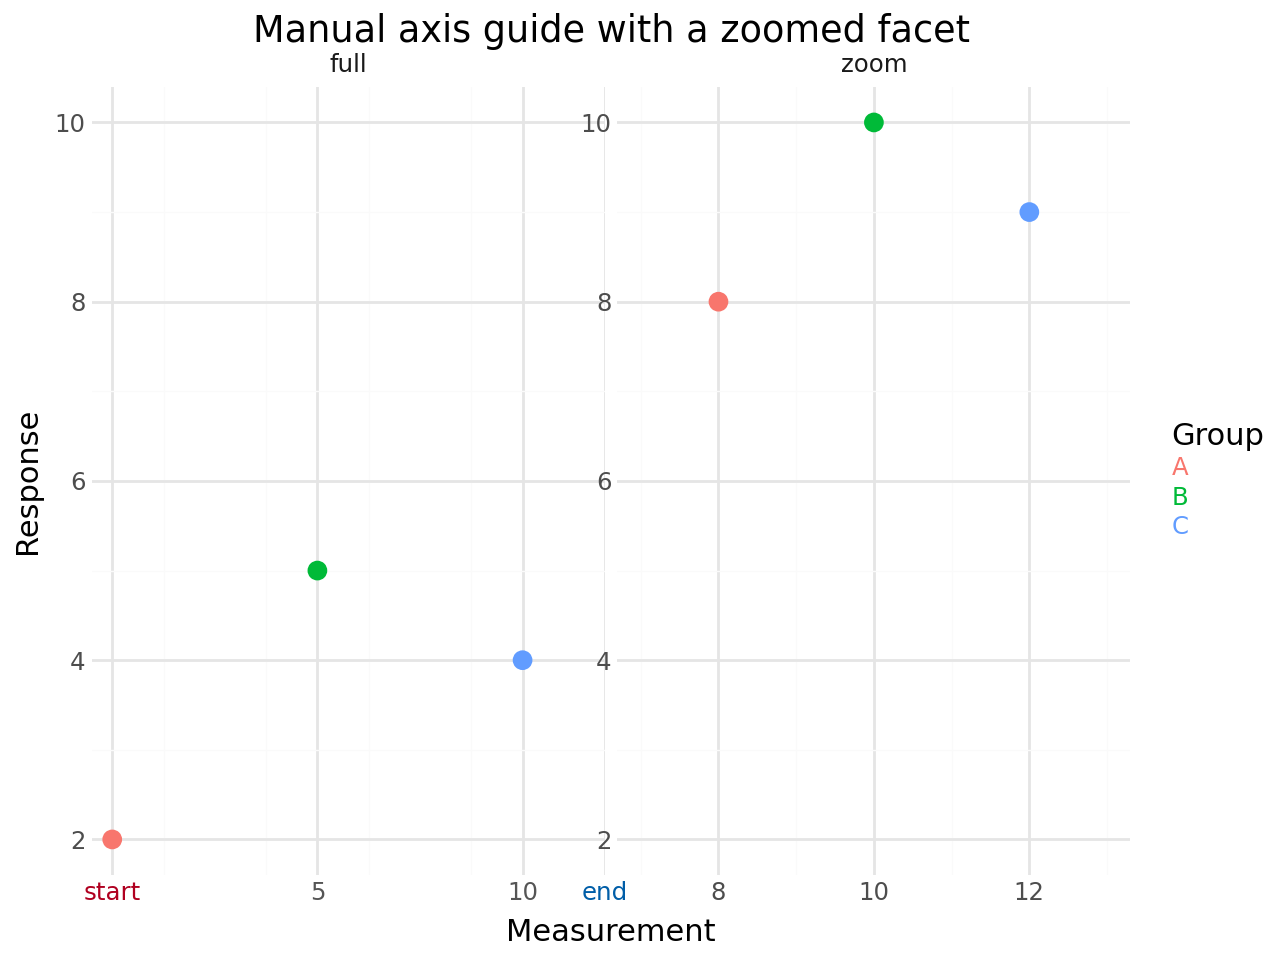

In [2]:
feature_df = pd.DataFrame({
    "panel": ["full", "full", "full", "zoom", "zoom", "zoom"],
    "x": [0, 5, 10, 8, 10, 12],
    "y": [2, 5, 4, 8, 10, 9],
    "group": ["A", "B", "C", "A", "B", "C"],
})

(
    ggplot(feature_df, aes("x", "y", color="group"))
    + geom_point(size=3)
    + facet_wrap2("panel", scales="free_x", axes="all")
    + scale_x_continuous(
        guide=guide_axis_manual(
            breaks=[0, 5, 10, 12],
            labels=["start", "5", "10", "end"],
            label_colour=["#b00020", "#555555", "#555555", "#005ea8"],
        )
    )
    + scale_x_facet('panel == "zoom"', limits=(7, 13), breaks=[8, 10, 12])
    + guides(color=guide_stringlegend(title="Group"))
    + labs(
        title="Manual axis guide with a zoomed facet",
        x="Measurement",
        y="Response",
    )
    + theme_minimal()
)

## Manual facet designs

`facet_manual()` uses a text design to place panels. Repeating a design label
creates a spanning panel, and `#` or `NA` marks an empty cell. Repeated labels
must form a rectangle; invalid designs raise a `ValueError` rather than silently
dropping panels.

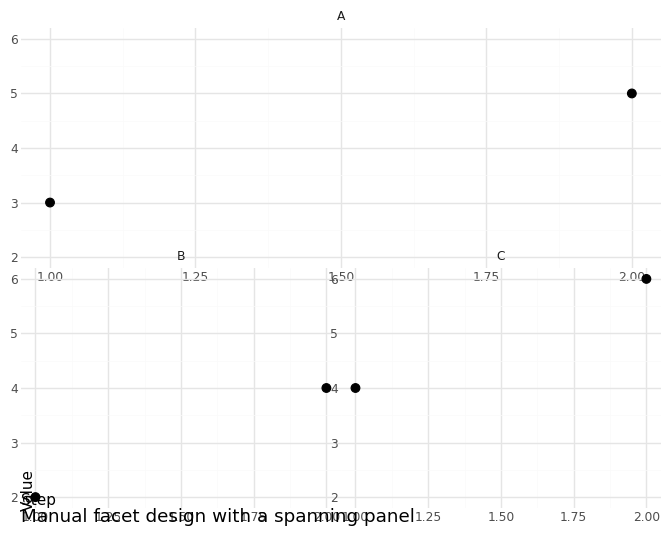

In [3]:
manual_df = pd.DataFrame({
    "panel": ["A", "A", "B", "B", "C", "C"],
    "x": [1, 2, 1, 2, 1, 2],
    "y": [3, 5, 2, 4, 4, 6],
})

manual_plot = (
    ggplot(manual_df, aes("x", "y"))
    + geom_point(size=3)
    + facet_manual("panel", design="AA\nBC", axes="all")
    + labs(
        title="Manual facet design with a spanning panel",
        x="Step",
        y="Value",
    )
    + theme_minimal()
)

manual_figure = manual_plot.draw()
manual_figure.set_layout_engine(None)
manual_figure

## Nested axis labels

`guide_axis_nested()` splits labels with a delimiter and draws a small nesting
line. Use it for categorical axes where each label has a parent and child
level.

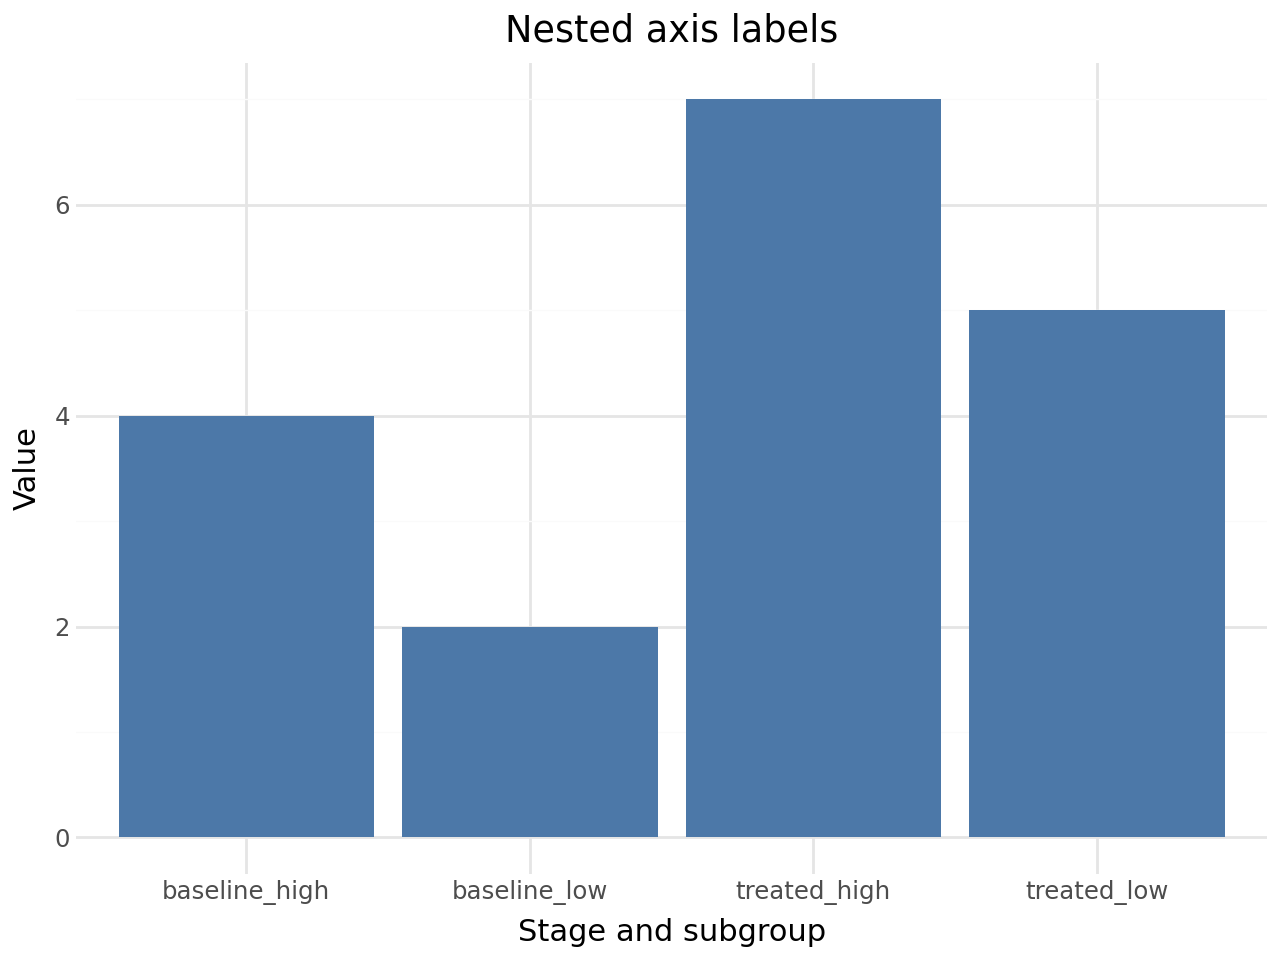

In [4]:
nested_df = pd.DataFrame({
    "stage": ["baseline_low", "baseline_high", "treated_low", "treated_high"],
    "value": [2, 4, 5, 7],
})

(
    ggplot(nested_df, aes("stage", "value"))
    + geom_col(fill="#4c78a8")
    + guide_axis_nested(delim="_")
    + labs(
        title="Nested axis labels",
        x="Stage and subgroup",
        y="Value",
    )
    + theme_minimal()
)

## Other guide helpers

The same rendering path also supports:

- `guide_axis_colour()` / `guide_axis_color()` for per-label colours
- `guide_axis_minor()` for visible minor ticks and optional minor labels
- `guide_axis_logticks()` for log-scale tick marks
- `guide_axis_truncated()` for spine bounds from numeric or callable limits
- `guide_axis_scalebar()` for data-coordinate scalebars
- `guide_dendro()` for dendrograms aligned to tick order
- `guide_stringlegend()` for colored text legends without key glyph boxes

Where plotnine lacks an equivalent ggh4x hook, plotnine-extra documents partial
support rather than exporting a silent no-op.